# Employee Attrition Prediction

## Phase 4: Feature Engineering

### Objective

The objective of this notebook is to identify the most important features that influence employee attrition.

Feature engineering helps improve machine learning models by selecting informative features and understanding their contribution to prediction.

This notebook includes:

- Loading the processed dataset
- Separating features and target variable
- Training a baseline Random Forest model
- Calculating feature importance
- Visualizing important features
- Selecting the most relevant features for modeling

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

## Load Processed Dataset

The processed dataset created during the preprocessing phase is loaded for feature engineering.

In [2]:
# Load processed dataset

df = pd.read_csv("../Dataset/Processed_Employee_Attrition.csv")

# Display first five rows

df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0.446350,0.590048,0.742527,1.401512,-1.010909,-0.891688,-0.937414,-0.660531,-1.224745,1.383138,...,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1
1,1.322365,-0.913194,-1.297775,-0.493817,-0.147150,-1.868426,-0.937414,0.254625,0.816497,-0.240677,...,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,0
2,0.008343,0.590048,1.414363,-0.493817,-0.887515,-0.891688,1.316673,1.169781,0.816497,1.284725,...,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1
3,-0.429664,-0.913194,1.461466,-0.493817,-0.764121,1.061787,-0.937414,1.169781,-1.224745,-0.486709,...,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,0
4,-1.086676,0.590048,-0.524295,-0.493817,-0.887515,-1.868426,0.565311,-1.575686,0.816497,-1.274014,...,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,0


#### Interpretation

The dataset has been loaded successfully.

It contains the cleaned and preprocessed employee information generated in the previous phase. All categorical variables have already been encoded into numerical values, making the dataset suitable for feature engineering.

#### Business Insight

A clean and consistent dataset ensures that feature importance analysis reflects genuine employee characteristics rather than inconsistencies caused by missing values or text-based categories.

## Verify Dataset

Before beginning feature engineering, it is important to verify the structure of the processed dataset.

In [3]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float64
 1   BusinessTravel            1470 non-null   float64
 2   DailyRate                 1470 non-null   float64
 3   Department                1470 non-null   float64
 4   DistanceFromHome          1470 non-null   float64
 5   Education                 1470 non-null   float64
 6   EducationField            1470 non-null   float64
 7   EnvironmentSatisfaction   1470 non-null   float64
 8   Gender                    1470 non-null   float64
 9   HourlyRate                1470 non-null   float64
 10  JobInvolvement            1470 non-null   float64
 11  JobLevel                  1470 non-null   float64
 12  JobRole                   1470 non-null   float64
 13  JobSatisfaction           1470 non-null   float64
 14  MaritalStatus      

In [4]:
# Display dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 31)


#### Interpretation

The processed dataset contains **1,470 employee records** and **31 numerical features**, including the target variable **Attrition**.

No missing values or categorical (`object`) data types remain, confirming that the preprocessing phase was completed successfully and the dataset is ready for feature engineering.

#### Business Insight

Having a fully numerical dataset allows machine learning algorithms to learn meaningful relationships efficiently.

A well-prepared dataset reduces preprocessing errors and improves the reliability of feature importance analysis.

## Separate Features and Target Variable

Machine learning models require the predictor variables and target variable to be separated before training.

In [6]:
# Separate predictor variables and target variable

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (1470, 30)
Target Shape: (1470,)


#### Interpretation

The dataset has been divided into **30 predictor variables** and **1 target variable (Attrition)**.

The predictor variables will be used to estimate feature importance, while the target variable represents whether an employee stayed or left the organization.

#### Business Insight

Separating predictors from the target variable ensures that the machine learning model learns patterns that explain employee attrition rather than accidentally using the answer itself during training.

## Train Baseline Random Forest Model

A Random Forest classifier is used to estimate feature importance.

Random Forest is selected because it naturally ranks features based on how much they contribute to decision-making across multiple decision trees.

In [7]:
# Initialize Random Forest model

rf = RandomForestClassifier(
    random_state=42
)

# Train the model

rf.fit(X, y)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


#### Interpretation

The Random Forest model has been successfully trained using all available predictor variables.

At this stage, the objective is not to maximize prediction accuracy but to calculate the relative importance of each feature in predicting employee attrition.

#### Business Insight

Understanding which employee characteristics contribute most to attrition enables organizations to focus on the factors that have the greatest impact on employee retention.

Instead of making assumptions, HR teams can make data-driven decisions based on measurable evidence.

## Calculate Feature Importance

After training the Random Forest model, feature importance scores are calculated.

These scores indicate how much each feature contributes to predicting employee attrition. Features with higher importance have a greater influence on the model's decision-making process.

In [8]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Reset index

feature_importance.reset_index(drop=True, inplace=True)

# Display feature importance

feature_importance

,Feature,Importance
0,MonthlyIncome,0.080500
1,Age,0.063493
2,DailyRate,0.057405
3,OverTime,0.055715
4,TotalWorkingYears,0.053946
5,MonthlyRate,0.051290
6,HourlyRate,0.050164
7,DistanceFromHome,0.048567
8,YearsAtCompany,0.039359
9,NumCompaniesWorked,0.035632


#### Interpretation

The table ranks all features according to their importance scores generated by the Random Forest model.

A higher importance score indicates that the feature contributes more to predicting employee attrition, whereas lower scores suggest a relatively smaller influence.

#### Business Insight

Feature importance enables HR professionals to identify which employee characteristics have the greatest impact on attrition.

Rather than relying on assumptions, organizations can prioritize interventions based on the most influential factors identified by the model.

## Top 15 Most Important Features

To improve readability, the fifteen most influential features are selected for visualization.

Focusing on the top-ranked features makes it easier to identify the strongest predictors of employee attrition.

In [9]:
# Select top 15 important features

top_features = feature_importance.head(15)

# Display

top_features

,Feature,Importance
0,MonthlyIncome,0.080500
1,Age,0.063493
2,DailyRate,0.057405
3,OverTime,0.055715
4,TotalWorkingYears,0.053946
5,MonthlyRate,0.051290
6,HourlyRate,0.050164
7,DistanceFromHome,0.048567
8,YearsAtCompany,0.039359
9,NumCompaniesWorked,0.035632


#### Interpretation

The table displays the fifteen features that contribute the most to predicting employee attrition.

These features will be analyzed further through visualization.

## Feature Importance Visualization

The following bar chart visualizes the relative importance of the top fifteen features identified by the Random Forest model.

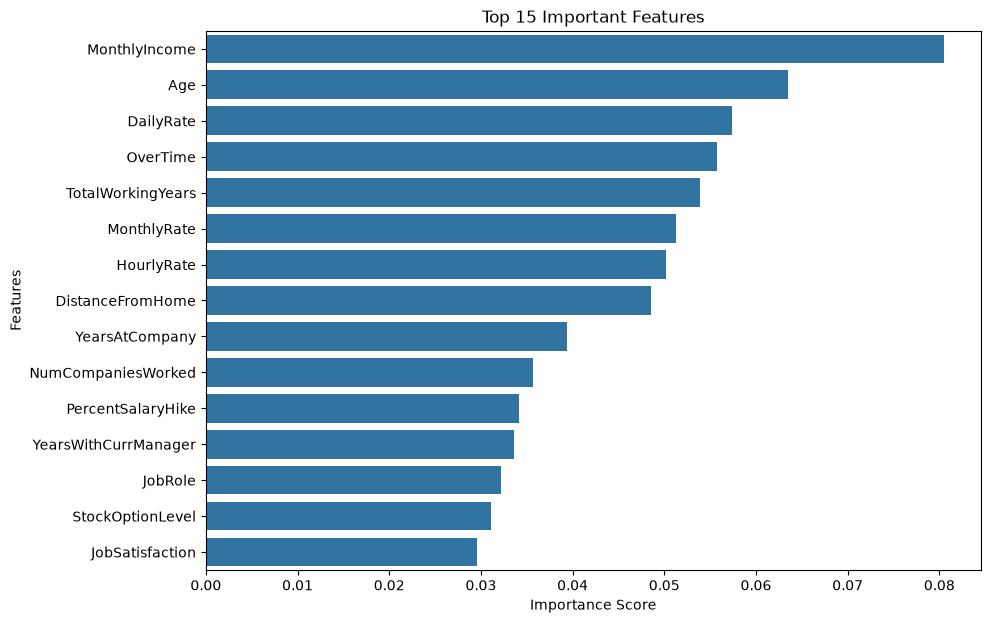

In [13]:
# Create figure

plt.figure(figsize=(10,7))

# Plot feature importance

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

# Title

plt.title("Top 15 Important Features")

# Labels

plt.xlabel("Importance Score")
plt.ylabel("Features")

# Show plot

plt.show()

## Summary of Important Features

The following table summarizes the most influential features identified during feature importance analysis.

In [15]:
# Display top 10 features

top_features.head(10)

,Feature,Importance
0,MonthlyIncome,0.080500
1,Age,0.063493
2,DailyRate,0.057405
3,OverTime,0.055715
4,TotalWorkingYears,0.053946
5,MonthlyRate,0.051290
6,HourlyRate,0.050164
7,DistanceFromHome,0.048567
8,YearsAtCompany,0.039359
9,NumCompaniesWorked,0.035632


### Interpretation

The Random Forest model estimates the relative importance of each feature in predicting employee attrition.

The results indicate that **MonthlyIncome**, **Age**, **DailyRate**, **OverTime**, and **TotalWorkingYears** contribute the most to the prediction process.

This suggests that employee compensation, experience, workload, and career progression play a significant role in attrition behavior.

Although some features have lower importance scores, they may still improve the overall predictive performance when used together with other variables.

The selected important features will be retained for model building in the next notebook.

# Business Recommendations

Based on the feature engineering and feature importance analysis, the following recommendations can help reduce employee attrition.

## Recommendation 1: Improve Employee Compensation

Monthly Income is the most influential feature affecting attrition.

The organization should regularly review salary structures and ensure competitive compensation to improve employee retention.

### Summary

The feature engineering process not only prepares the data for machine learning but also provides valuable business insights.

These recommendations can assist HR departments in designing policies that reduce employee turnover and improve workforce stability.

## Recommendation 4: Focus on Employee Satisfaction

Job Satisfaction and Stock Option Level also contribute to employee retention.

Regular employee feedback sessions and better reward programs may help improve overall satisfaction.

## Recommendation 3: Career Growth Programs

Features such as YearsAtCompany and TotalWorkingYears indicate that career progression influences employee decisions.

Providing promotions, skill development programs, and internal career opportunities may improve long-term retention.

## Recommendation 2: Monitor Employee Workload

OverTime is among the strongest predictors of attrition.

Employees working excessive overtime should be identified early and workload should be balanced to reduce burnout.

# Saving the Processed Dataset

The final processed dataset is saved for use in the Model Building notebook.

Saving the processed dataset eliminates the need to repeat preprocessing steps and ensures consistency throughout the machine learning pipeline.

In [20]:
# Verify the final dataset

print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (1470, 31)


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0.446350,0.590048,0.742527,1.401512,-1.010909,-0.891688,-0.937414,-0.660531,-1.224745,1.383138,...,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1
1,1.322365,-0.913194,-1.297775,-0.493817,-0.147150,-1.868426,-0.937414,0.254625,0.816497,-0.240677,...,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,0
2,0.008343,0.590048,1.414363,-0.493817,-0.887515,-0.891688,1.316673,1.169781,0.816497,1.284725,...,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1
3,-0.429664,-0.913194,1.461466,-0.493817,-0.764121,1.061787,-0.937414,1.169781,-1.224745,-0.486709,...,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,0
4,-1.086676,0.590048,-0.524295,-0.493817,-0.887515,-1.868426,0.565311,-1.575686,0.816497,-1.274014,...,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,0


### Interpretation

The dataset has been successfully cleaned, transformed, and prepared for machine learning.

The displayed dataset confirms that preprocessing operations such as feature selection, encoding, and scaling have been successfully applied.

In [21]:
# Save the processed dataset

df.to_csv("../Dataset/Processed_Employee_Attrition.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


### Interpretation

The processed dataset has been exported successfully.

This dataset will now be used directly in the Model Building notebook, ensuring that every machine learning model is trained on the same preprocessed data.

# Conclusion

The Feature Engineering phase has been completed successfully.

During this phase:

- Irrelevant features were removed.
- Categorical variables were encoded.
- Numerical features were standardized.
- Feature importance analysis identified the most influential predictors of employee attrition.
- Business recommendations were derived from the analysis.
- The final processed dataset was saved for future model training.

The dataset is now fully prepared for the Model Building phase, where multiple machine learning algorithms will be trained, evaluated, and compared to identify the best-performing model for employee attrition prediction.